
## Lab1.1: Análisis exploratorio de datos con PANDAS y NUMPY

In [3]:
import seaborn as sns
import pandas as pd
import numpy as np

data = sns.load_dataset("penguins").dropna().values
df = pd.DataFrame(data, columns=["especie", "isla", "longitud_pico (mm)", "profundidad_pico (mm)", "longitud_aleta (mm)", "masa_corporal (g)", "genero"])

df[:5]

,especie,isla,longitud_pico (mm),profundidad_pico (mm),longitud_aleta (mm),masa_corporal (g),genero
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


Esto cargará un dataframe (df), usando la librería seaborn, con algunas características morfológicas y geográficas de diferentes especies de pingüinos. Las colujmnas contienen los siguientes datos:

```
[especie, isla, longitud del pico, profundidad del pico, longitud de la aleta, masa corporal, genero]
```

https://github.com/allisonhorst/palmerpenguins/blob/main/man/figures/lter_penguins.png

## Laboratorio_1.1

1.   ¿Cuáles son las profundidades del pico máxima y mínima de los pinguinos de la isla Torgersen?

2.    ¿De qué isla, especie y género es el pingüino con la mayor masa corporal?
       **Ayuda:** utilice la función `argmax()`

3.   ¿Cuál es la masa corporal media de los pinguinos macho que no son de la especie Gentoo?

4.   Grafique la distribución de la longitud del pico. Añada el valor medio y la desviación estándar en el título de la figura. **Ayuda:** utilice la funcion `hist()`

5.   ¿Cuáles son las islas y especies presentes en el conjunto de datos? ¿Con qué frecuencia aparecen? Grafique la distribución de la masa corporal para los pingüinos.




  



In [4]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = sns.load_dataset("penguins").dropna().values

df = pd.DataFrame(
    data,
    columns=[
        "especie",
        "isla",
        "longitud_pico (mm)",
        "profundidad_pico (mm)",
        "longitud_aleta (mm)",
        "masa_corporal (g)",
        "genero"
    ]
)

df[:5]

,especie,isla,longitud_pico (mm),profundidad_pico (mm),longitud_aleta (mm),masa_corporal (g),genero
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [5]:
# 1 filtrar pinguinos

torgersen = df.loc[df.isla == "Torgersen", :]

print("Profundidad mínima del pico =",
      torgersen["profundidad_pico (mm)"].astype(float).min(), "mm")

print("Profundidad máxima del pico =",
      torgersen["profundidad_pico (mm)"].astype(float).max(), "mm")

Profundidad mínima del pico = 15.9 mm
Profundidad máxima del pico = 21.5 mm


BIEN..

In [6]:
#2 posición pinguino mayor masa

posicion = np.argmax(df["masa_corporal (g)"].astype(float).values)

print("Posición:", posicion)
print("Isla:", df.iloc[posicion]["isla"])
print("Especie:", df.iloc[posicion]["especie"])
print("Género:", df.iloc[posicion]["genero"])
print("Masa corporal:",
      df.iloc[posicion]["masa_corporal (g)"], "g")

Posición: 231
Isla: Biscoe
Especie: Gentoo
Género: Male
Masa corporal: 6300.0 g


In [7]:
#3

machos_no_gentoo = df.loc[
    (df.genero == "Male") & (df.especie != "Gentoo"),
    :
]

media_masa = machos_no_gentoo["masa_corporal (g)"].astype(float).mean()

print("Masa corporal media =", media_masa, "g")

Masa corporal media = 4010.2803738317757 g


In [8]:
print("Masa corporal media = {:.2f} g".format(media_masa))

Masa corporal media = 4010.28 g


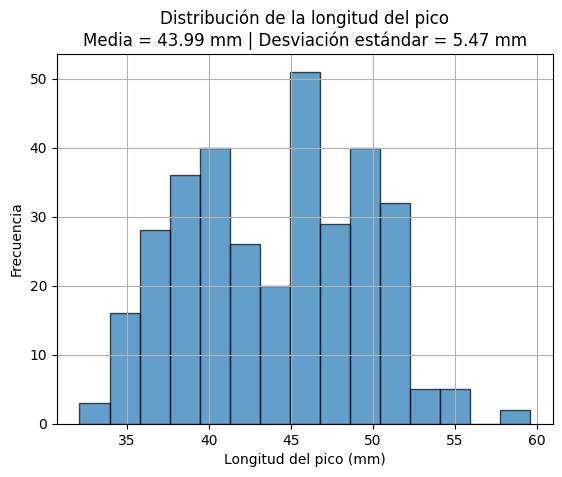

In [14]:
#4

longitud_pico = df["longitud_pico (mm)"].astype(float)

media = longitud_pico.mean()
desviacion = longitud_pico.std()

plt.hist(longitud_pico, bins=15, alpha=0.7, edgecolor="black")

plt.xlabel("Longitud del pico (mm)")
plt.ylabel("Frecuencia")

plt.title(
    "Distribución de la longitud del pico\n"
    "Media = {:.2f} mm | Desviación estándar = {:.2f} mm".format(
        media, desviacion
    )
)

plt.grid()
plt.show()

BIEN

Frecuencia de las islas:
isla
Biscoe       163
Dream        123
Torgersen     47
Name: count, dtype: int64
Frecuencia de las especies:
especie
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64


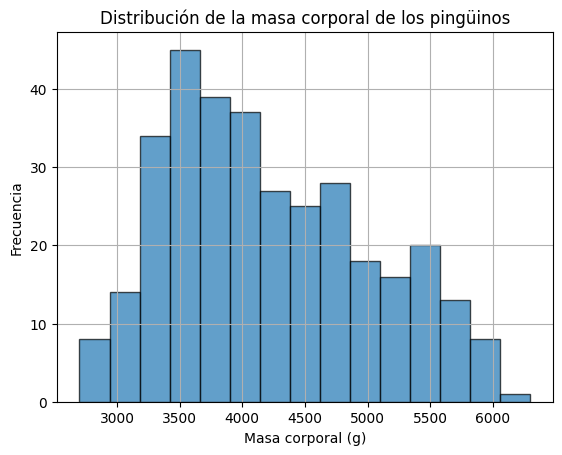

In [15]:
#5 frecuencia isla

print("Frecuencia de las islas:")
print(df["isla"].value_counts())
print("Frecuencia de las especies:")
print(df["especie"].value_counts())
masa = df["masa_corporal (g)"].astype(float)

plt.hist(masa, bins=15, alpha=0.7, edgecolor="black")

plt.xlabel("Masa corporal (g)")
plt.ylabel("Frecuencia")
plt.title("Distribución de la masa corporal de los pingüinos")

plt.grid()
plt.show()

MUY BIEN NOTA 5.0